In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

from mis_dro.plot import *
from mis_dro.experiments import ExperimentName

from matplotlib import rc
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], "size":14})
rc('text', usetex=True)

In [2]:
experiment_name = ExperimentName.kl_newsvendor_1d
experiment_dir = Path(f"/Users/patrick/experiments/misdro/paper_bas/{experiment_name.value}")
# experiment_dir = Path(f"/dcs/large/u1508153/misdro/dro_bas/{experiment_name.value}")
assert experiment_dir.exists()
all_results_df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])

num_total_samples = []
for _, row in all_results_df.iterrows():
    if row["algorithm"] == "kl_bdro":
        num_total_samples.append(row["num_likelihood_samples"] ** 2)
    elif row["algorithm"] == "kl_dro_bas":
        num_total_samples.append(row["num_likelihood_samples"])
all_results_df["num_total_samples"] = num_total_samples
all_results_df

solution  \
uuid                                 replication                         
99054ac5-d1c6-4ff1-b027-bb65789b1256 0                           [inf]   
                                     1                           [inf]   
                                     2                           [inf]   
                                     3                           [inf]   
                                     4                           [inf]   
...                                                                ...   
ec122d51-75a5-4a55-a4f7-a548ef4dfbee 495          [24.790105194115803]   
                                     496          [30.396169125007546]   
                                     497           [22.80875825215784]   
                                     498          [24.702719378284158]   
                                     499           [32.11224486433873]   

                                                  dgp_time  likelihood_time  \
uuid                                 replication                              
99054ac5-d1c6-4ff1-b027-bb65789b1256 0            0.002013         0.000017   
                                     1            0.000224         0.000012   
                                     2            0.000182         0.000010   
                                     3            0.000186         0.000012   
                                     4            0.000164         0.000011   
...                                                    ...              ...   
ec122d51-75a5-4a55-a4f7-a548ef4dfbee 495          0.000252         0.002478   
                                     496          0.000277         0.002493   
                                     497          0.000261         0.002532   
                                     498          0.000263         0.002583   
                                     499          0.000274         0.002502   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
99054ac5-d1c6-4ff1-b027-bb65789b1256 0                  0.001542    0.000014   
                                     1                  0.000051    0.000010   
                                     2                  0.000051    0.000009   
                                     3                  0.000050    0.000009   
                                     4                  0.000046    0.000009   
...                                                          ...         ...   
ec122d51-75a5-4a55-a4f7-a548ef4dfbee 495                0.000096    2.756237   
                                     496                0.000097    2.754286   
                                     497                0.000092    2.826385   
                                     498                0.000095    2.810779   
                                     499                0.000096    2.728749   

                                                  setup_time  \
uuid                                 replication               
99054ac5-d1c6-4ff1-b027-bb65789b1256 0                   0.0   
                                     1                   0.0   
                                     2                   0.0   
                                     3                   0.0   
                                     4                   0.0   
...                                                      ...   
ec122d51-75a5-4a55-a4f7-a548ef4dfbee 495                 NaN   
                                     496                 NaN   
                                     497                 NaN   
                                     498                 NaN   
                                     499                 NaN   

                                                  log_partition_constant  \
uuid                                 replication                           
99054ac5-d1c6-4ff1-b027-bb65789b1256 0       

In [3]:
# NOTE filter by DGP
filter_dgp = "exponential"
results_df = all_results_df.loc[all_results_df["dgp"] == filter_dgp]

# NOTE filter out when log_partition_constant G is less than epsilon
results_df = results_df.loc[results_df["log_partition_constant"] < results_df["epsilon"]]

def convert_str_to_float_list(str_list: str, list_len: int) -> list[float]:
    if str_list == "[]":
        return [np.nan for _ in range(list_len)]
    else:
        return [float(x) for x in str_list.strip('[]').split(',')]

# NOTE we always want the same number of test observations
assert np.isclose(results_df["num_test_observations"].var(), 0)
num_test_observations = results_df["num_test_observations"].unique()[0]
results_df["out_of_sample_cost"] = results_df["out_of_sample_cost"].map(lambda x: convert_str_to_float_list(x, num_test_observations))

# special case for 1 test observation
if num_test_observations == 1:
    results_df["out_of_sample_cost"] = results_df["out_of_sample_cost"].map(lambda x: x[0])
else:
    raise NotImplementedError("Not supported yet!")

results_df["out_of_sample_cost"]

uuid                                  replication
0135dfcb-efcb-4d6f-91f6-d631f023591a  0               93.207014
                                      1               34.659102
                                      2               53.285306
                                      3               69.057372
                                      4              335.993068
                                                        ...    
ec122d51-75a5-4a55-a4f7-a548ef4dfbee  495             53.456510
                                      496             65.946304
                                      497            262.306309
                                      498              1.324364
                                      499             78.918887
Name: out_of_sample_cost, Length: 90000, dtype: float64

In [4]:

agg_df = get_agg_df(results_df, ["algorithm", "dgp", "epsilon", "num_total_samples"])
agg_df

/Users/patrick/Projects/mis-dro-code/mis_dro/plot.py:184: FutureWarning: The provided callable <function mean at 0x10faa99e0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/Users/patrick/Projects/mis-dro-code/mis_dro/plot.py:184: FutureWarning: The provided callable <function var at 0x10faa9c60> is currently using SeriesGroupBy.var. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "var" instead.
  agg_df = gb.agg(
/Users/patrick/Projects/mis-dro-code/mis_dro/plot.py:184: FutureWarning: The provided callable <function mean at 0x10faa99e0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/Users/patrick/Projects/mis-dro-code/mis_dro/plot.py

out_of_sample_mean  \
algorithm  dgp         epsilon num_total_samples                       
kl_bdro    exponential 0.001   25                          83.730045   
                               100                         82.616454   
                               900                         81.082364   
                               2500                        81.439821   
                       0.002   25                          83.719192   
...                                                              ...   
kl_dro_bas exponential 2.500   2500                       282.755612   
                       3.000   25                         120.736214   
                               100                        167.829113   
                               900                        252.250521   
                               2500                       288.253397   

                                                  out_of_sample_var  \
algorithm  dgp         epsilon num_total_samples                      
kl_bdro    exponential 0.001   25                       9958.297608   
                               100                      9780.323312   
                               900                      9742.094036   
                               2500                     9692.372502   
                       0.002   25                       9963.411087   
...                                                             ...   
kl_dro_bas exponential 2.500   2500                    10995.211038   
                       3.000   25                       6619.640087   
                               100                      7378.477634   
                               900                     10428.630426   
                               2500                    11185.563278   

                                                  mean_solve_time  \
algorithm  dgp         epsilon num_total_samples                    
kl_bdro    exponential 0.001   25                        0.064954   
                               100                       0.151696   
                               900                       0.771286   
                               2500                      2.749790   
                       0.002   25                        0.065512   
...                                                           ...   
kl_dro_bas exponential 2.500   2500                      5.972758   
                       3.000   25                        0.023206   
                               100                       0.034799   
                               900                       0.375924   
                               2500                      6.004708   

                                                  std_solve_time  
algorithm  dgp         epsilon num_total_samples                  
kl_bdro    exponential 0.001   25                       0.011567  
                               100                      0.019553  
                               900                      0.032520  
                               2500                     0.138254  
                       0.002   25                       0.010921  
...                                                          ...  
kl_dro_bas exponential 2.500   2500                     0.091262  
                       3.000   25                       0.003282  
                               100                      0.003326  
                               900                      0.010343  
                               2500                     0.101451  

[180 rows x 4 columns]

## Plot mean-variance trade-off

For each DGP, we plot the out-of-sample mean $\hat{\mu}_M(\epsilon)$ and variance $\hat{\sigma}_M(\epsilon)$ of Bayesian DRO with different posteriors.

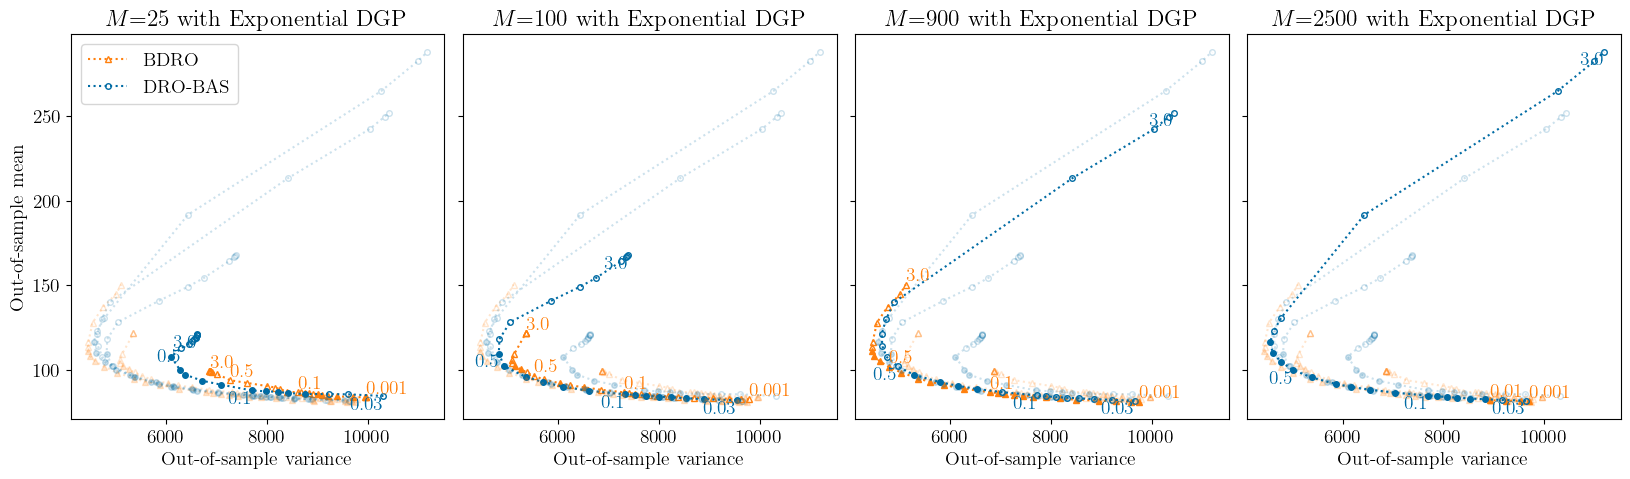

In [5]:
total_samples_list = agg_df.index.get_level_values("num_total_samples").unique().tolist()
dgp_list = agg_df.index.get_level_values("dgp").unique().tolist()

nrows = len(dgp_list)
ncols = len(total_samples_list)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(5*ncols, nrows*5))
fig.subplots_adjust(wspace=0.05)
pd.options.mode.chained_assignment = None  # default='warn'

for i, dgp in enumerate(dgp_list):
    for j, total_samples in enumerate(total_samples_list):
        axis_df = agg_df.loc[:, dgp, :, total_samples]
        axis_df.loc[:, "is_pareto_front"] = is_minimise_pareto_front(axis_df["out_of_sample_var"].values, axis_df["out_of_sample_mean"].values)
        for algorithm in axis_df.index.get_level_values("algorithm").unique():
            df = axis_df.loc[algorithm, :]
            for k in range(len(total_samples_list)):
                alpha = 1.0
                is_labelled=True
                if j != k:
                    alpha = 0.2
                    is_labelled = False
                mean_variance_plot(axes[k], df, **algorithm_inference_style(algorithm, "bayes", label_inference=False), offset=0.0, is_labelled=is_labelled, alpha=alpha)
        if j == 0:
            axes[j].legend()
            axes[j].set_ylabel("Out-of-sample mean")
        axes[j].set_title("$M$" + f"={total_samples} with {NiceNameDGP[filter_dgp]}")
        axes[j].set_xlabel("Out-of-sample variance")

# fig.savefig(f"/Users/patrick/Experiments/misdro/paper_bas_figures/{experiment_name}_{filter_dgp}.pdf", bbox_inches="tight")

## Solve time

In [6]:

# solve_time_df = results_df.groupby(["algorithm", "num_total_samples"]).agg({"solve_time": ["mean", "std"]}).unstack(level="algorithm").swaplevel(1,2, axis="columns")

results_df["sample_time"] = results_df["likelihood_time"] + results_df["posterior_time"]
gb = results_df.groupby(["algorithm", "num_total_samples"])
solve_time_df = gb.agg(
    mean_solve_time = pd.NamedAgg(column="solve_time", aggfunc=np.mean),
    std_solve_time = pd.NamedAgg(column="solve_time", aggfunc=np.std),
    mean_sample_time = pd.NamedAgg(column="sample_time", aggfunc=np.mean),
    std_sample_time = pd.NamedAgg(column="sample_time", aggfunc=np.std),
)
solve_time_df = solve_time_df.round(decimals=4)
solve_time_df["str_solve_time"] = solve_time_df[["mean_solve_time", "std_solve_time"]].apply(
    lambda x: f"{x['mean_solve_time']} ({x['std_solve_time']})", axis=1
)
solve_time_df["str_sample_time"] = solve_time_df[["mean_sample_time", "std_sample_time"]].apply(
    lambda x: f"{x['mean_sample_time']} ({x['std_sample_time']})", axis=1
)
print(solve_time_df[["str_solve_time", "str_sample_time"]].unstack(level="algorithm").to_latex())
# solve_time_df[["mean_solve_time", "std_solve_time"]].apply(lambda x: x.mean_solve_time + x.std_solve_time, axis=1)

\begin{tabular}{lllll}
\toprule
 & \multicolumn{2}{r}{str_solve_time} & \multicolumn{2}{r}{str_sample_time} \\
algorithm & kl_bdro & kl_dro_bas & kl_bdro & kl_dro_bas \\
num_total_samples &  &  &  &  \\
\midrule
25 & 0.0658 (0.0111) & 0.0235 (0.0035) & 0.0004 (0.0) & 0.0001 (0.0) \\
100 & 0.1459 (0.0198) & 0.036 (0.0038) & 0.0006 (0.0) & 0.0001 (0.0) \\
900 & 0.7215 (0.0405) & 0.4222 (0.0315) & 0.0016 (0.0001) & 0.0001 (0.0) \\
2500 & 2.7304 (0.1423) & 6.1704 (0.1379) & 0.0028 (0.0002) & 0.0001 (0.0) \\
\bottomrule
\end{tabular}



/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_13194/4006273325.py:5: FutureWarning: The provided callable <function mean at 0x10faa99e0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  solve_time_df = gb.agg(
/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_13194/4006273325.py:5: FutureWarning: The provided callable <function std at 0x10faa9b20> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  solve_time_df = gb.agg(
/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_13194/4006273325.py:5: FutureWarning: The provided callable <function mean at 0x10faa99e0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "

# Constant $G(\tau_n)$ and expected KL

In [7]:

from bayesian_dro.Bayesian_DRO_continuous import DGP_STD_TRUNCATED_NORMAL
from mis_dro.constants import NUM_REPLICATIONS, NUM_OBSERVATIONS, NUM_TEST_OBSERVATIONS
from mis_dro.dataset import sample_dgp
from mis_dro.bayes_conjugates import default_prior_params, get_posterior_params, get_log_partition_constant, derive_analytical_posterior_params
from mis_dro.newsvendor import BACKORDER_COST, HOLDING_COST, newsvendor_cost_cvxpy

def normal_newsvendor_optimal_solution(dgp_mean, dgp_std):
    return sp.stats.norm.ppf(BACKORDER_COST / (BACKORDER_COST + HOLDING_COST), dgp_mean, dgp_std)


def expected_kl_normal_gamma(dgp_mean, dgp_std, theta_params):
    mu_posterior, _, alpha_posterior, beta_posterior = theta_params
    dgp_precision = 1 / (dgp_std ** 2)
    term1 = np.log(np.sqrt(dgp_precision * (beta_posterior / alpha_posterior)))
    term2 = (dgp_std ** 2 + (dgp_mean - mu_posterior)**2) / (2 * (beta_posterior / alpha_posterior))
    return term1 + term2 - 0.5 + get_log_partition_constant("normal_gamma", theta_posterior)

dgp = "multivariate_normal"
posterior = "normal_inverse_wishart"
num_observations = NUM_OBSERVATIONS
G_constant = []             # calculate the constant G
posterior_expected_kl = []  # assuming normal DGP, what is expectation under the posterior of the KL between the DGP and the likelihood?
prior_expected_kl = []      # assuming normal DGP, what is expectation under the prior of the KL between the DGP and the likelihood?
opt_sol = normal_newsvendor_optimal_solution(25, DGP_STD_TRUNCATED_NORMAL)  # optimal solution

opt_costs = np.zeros((NUM_REPLICATIONS, NUM_TEST_OBSERVATIONS))
for j in range(NUM_REPLICATIONS):
    generator = np.random.default_rng(seed=j)
    data = sample_dgp(
        dgp, num_observations, generator=generator
    )
    data_eval = sample_dgp(
        dgp, NUM_TEST_OBSERVATIONS, contamination=0.0, generator=generator
    )
    theta_prior = default_prior_params(posterior)
    theta_posterior = get_posterior_params(posterior, data, theta_prior)
    G_constant.append(get_log_partition_constant(posterior, theta_posterior))
    posterior_expected_kl.append(expected_kl_normal_gamma(25, DGP_STD_TRUNCATED_NORMAL, theta_posterior))
    prior_expected_kl.append(expected_kl_normal_gamma(25, DGP_STD_TRUNCATED_NORMAL, theta_prior))
    opt_costs[j] = newsvendor_cost_cvxpy(opt_sol, data_eval).value
np.max(G_constant), np.var(G_constant)

[[34.40648987]]


ValueError: Dimension mismatch: array 'cov' is of shape (1, 1), but 'mean' is a vector of length 5.

In [ ]:
np.mean(posterior_expected_kl), np.var(posterior_expected_kl)

(0.08892539135699731, 0.0022999465683889984)

In [ ]:
np.mean(prior_expected_kl), np.var(prior_expected_kl)

(359.7442957726813, 0.0)

# Mean squared error between our solution and the solution under the DGP


In [ ]:
mean_cost = np.mean(opt_costs, axis=1)
var_cost = np.var(opt_costs, axis=1)
mean_of_means = np.mean(mean_cost)
mean_of_variances = np.mean(var_cost)
var_of_means = np.var(mean_cost)
opt_sol, mean_of_variances, var_of_means

(31.045853465832373, 809.5869569415518, 16.31412063772674)

In [ ]:
def multivariate_digamma(a: float, p: int) -> float:
    """The multivariate digamma function of dimension p

    Notes:
        [1] https://search.r-project.org/CRAN/refmans/CholWishart/html/mvdigamma.html
        [2] https://en.wikipedia.org/wiki/Multivariate_gamma_function#Derivatives
    """
    return np.sum([sp.special.digamma(a + (1.0-i)/2.0) for i in range(p)])

def get_normal_inverse_wishart_G_constant(dim: int, kappa_post: float) -> float:
    """Returns the constant G(tau, nu) for the normal-inverse-Wishart"""
    term1 = -0.5 * dim * np.log(2)
    print(term1)
    term2 = - 0.5 * multivariate_digamma(0.5 * (kappa_post - dim - 2), dim)
    print(term2)
    term3 = dim / (2 * kappa_post)
    print(term3)
    term4 = dim * 0.5 * np.log(kappa_post - dim - 2)
    print(term4)
    # term5 = 0.5 * np.log(dim)
    # print(term5)
    return term1 + term2 + term3 + term4

In [ ]:
dim = 5
_, kappa_prior, _, _ = default_prior_params("normal_inverse_wishart", dim=dim)
kappa_post = kappa_prior +  20
kappa_prior, kappa_post

(13.0, 33.0)